# 11. Try to beat the Bayesian strategy 
1. Reproduce example from the lecture (electronic system production). 
2. Implement last three strategies from slide 105 plus one of your own (other than the two 
remaining in the slide), compare results in a plot. 
3. In real life it is possible that the quality of components from a manufacture changes in time. 
Implement “imperfect memory” in the Bayesian strategy that makes it gradually forget the 
learned parameters of Beta distribution for each batch. Check using an appropriate example.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

np.random.seed(42)

1. Reproduce example from the lecture (electronic system production). 

In [35]:
class Batch:
    
    def __init__(self, quality):
        self.quality = quality
        self.alpha = 1
        self.beta = 1
        self.count = 0
        
    def sample_distribution(self):
        return np.random.beta(self.alpha, self.beta)
    
    def get_element(self):
        good = np.random.rand() < self.quality
        self.alpha = self.alpha + int(good)
        self.beta = self.beta + 1 - int(good)
        self.count += 1
        
        return good

In [36]:
class Factory:
    batches = []
    systems = 0
    good = 0
    
    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.systems = 0
        self.good = 0
        
    def get_element(self):
        samples = [batch.sample_distribution() for batch in self.batches]
        
        probs = np.array(samples) / np.sum(samples) # normalize to probabilities
        choice = np.random.choice(len(self.batches), p=probs)
        result = self.batches[choice].get_element()
        
        self.systems = self.systems + 1
        self.good = self.good + int(result)


In [37]:
qualities = [0.3, 0.5, 0.7, 0.9] # unknown to the algorithm

factory = Factory()
factory.set_batches(qualities)

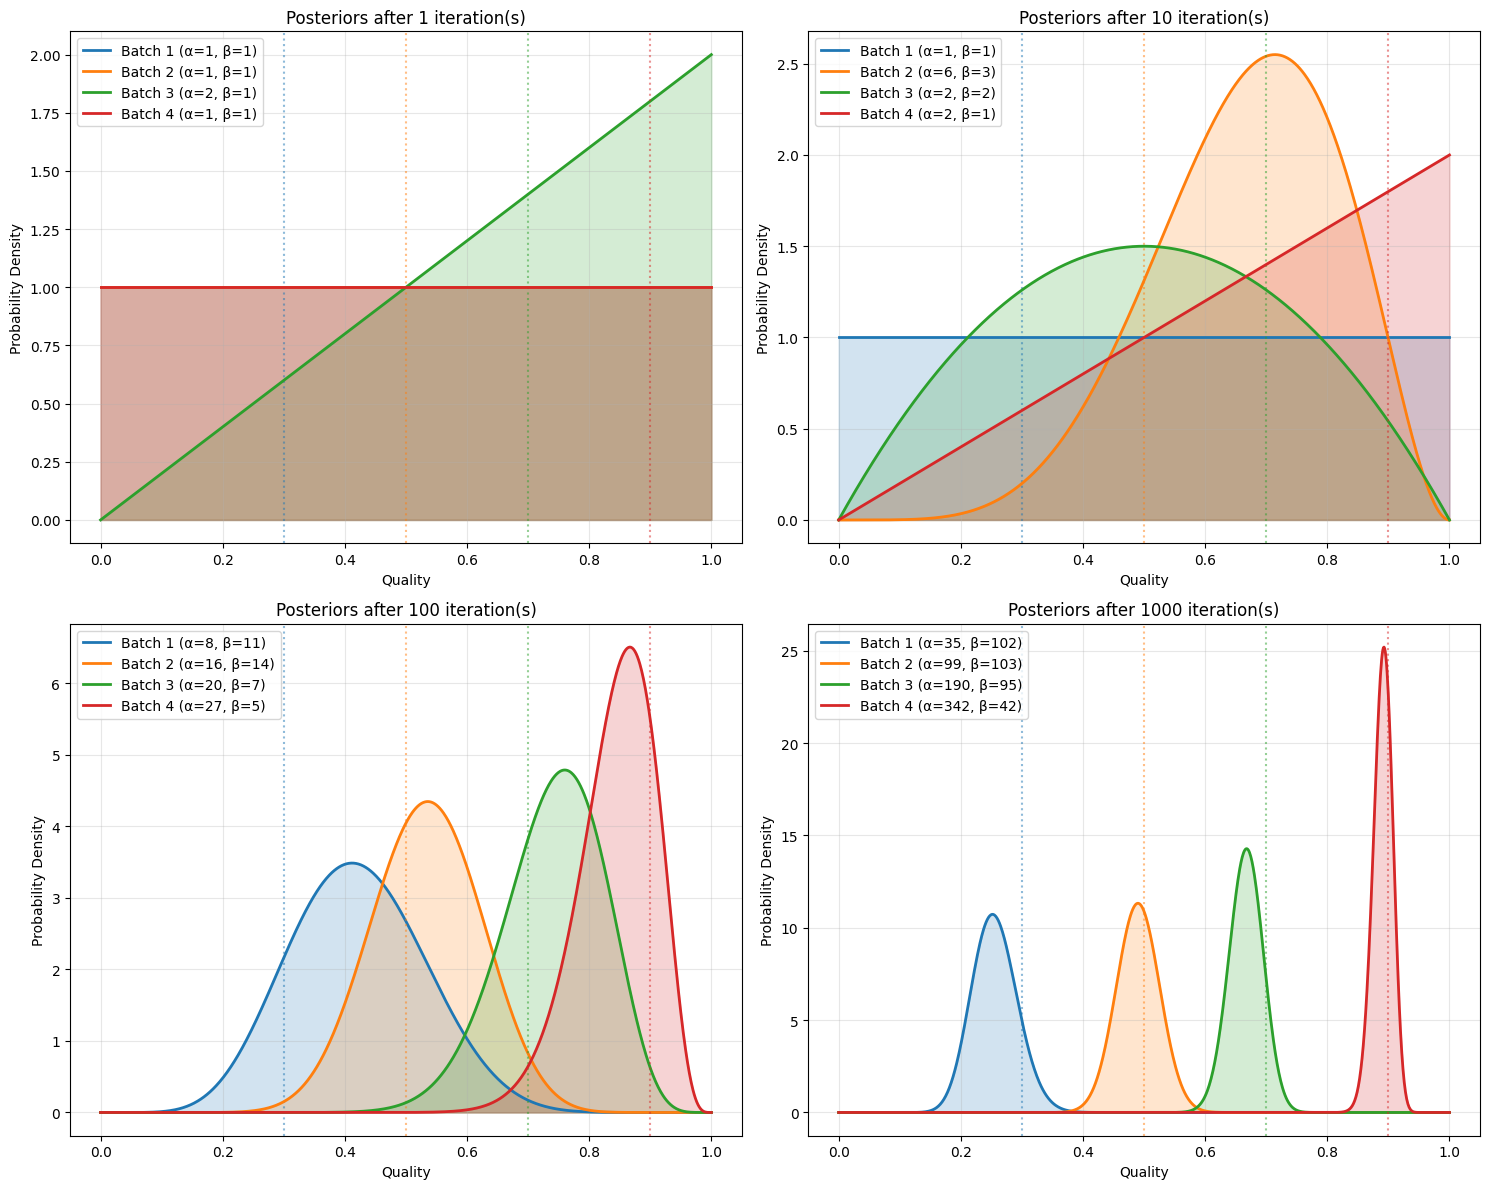

Batch 1 (quality=0.3): α=35, β=102, sampled 135 times, estimated quality=0.2555
Batch 2 (quality=0.5): α=99, β=103, sampled 200 times, estimated quality=0.4901
Batch 3 (quality=0.7): α=190, β=95, sampled 283 times, estimated quality=0.6667
Batch 4 (quality=0.9): α=342, β=42, sampled 382 times, estimated quality=0.8906
Batches: good=667, bad=333


In [43]:
def plot_posteriors(factory_class, iterations_to_show, qualities):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    factory = factory_class()
    factory.set_batches(qualities)
    
    iteration_counter = 0

    for idx, n_iter in enumerate(iterations_to_show):
        
        for i in range(iteration_counter, n_iter):
            factory.get_element()
            
        iteration_counter = n_iter
        
        ax = axes[idx]
        x = np.linspace(0, 1, 1000)
        for i, batch in enumerate(factory.batches):
            pdf = beta_dist.pdf(x, batch.alpha, batch.beta)
            color = f'C{i}'
            ax.plot(x, pdf, label=f'Batch {i+1} (α={batch.alpha}, β={batch.beta})', linewidth=2, color=color)
            ax.fill_between(x, pdf, alpha=0.2, color=color)
            ax.axvline(x=qualities[i], color=color, linestyle=':', alpha=0.5)
        
        ax.set_xlabel('Quality')
        ax.set_ylabel('Probability Density')
        ax.set_title(f'Posteriors after {n_iter} iteration(s)')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    for i, batch in enumerate(factory.batches):
        samples = batch.alpha + batch.beta - 2
        estimated_quality = batch.alpha / (batch.alpha + batch.beta)
        print(f"Batch {i+1} (quality={qualities[i]}): α={batch.alpha}, β={batch.beta}, sampled {samples} times, estimated quality={estimated_quality:.4f}")

def summarize_strategy(factory_factory, qualities, n_iter=1000):
    factory = factory_factory()
    factory.set_batches(qualities)
    for _ in range(n_iter):
        factory.get_element()
    good = factory.good
    bad = factory.systems - factory.good
    
    print(f"Batches: good={good}, bad={bad}")

def summarize_strategy_dynamic(factory_factory, qualities, n_iter=2000, change_at=500, batch_to_change=0, new_quality=0.9):
    factory = factory_factory()
    factory.set_batches(qualities)
    for i in range(n_iter):
        if i == change_at:
            factory.batches[batch_to_change].quality = new_quality
        factory.get_element()
    good = factory.good
    bad = factory.systems - factory.good

    print(f"Batches: good={good}, bad={bad}")

qualities = [0.3, 0.5, 0.7, 0.9]
iterations_to_show = [1, 10, 100, 1000]
plot_posteriors(Factory, iterations_to_show, qualities)
summarize_strategy(Factory, qualities, n_iter=1000)

We can see that as expected, first the choice is more or less random due to uniform Beta(1,1) priors. As evidence accumulates Beta distribution changes, so that the factory chooses the best batch more often and worse batches respectibely less often.

2. Implement last three strategies from slide 105 plus one of your own (other than the two 
remaining in the slide), compare results in a plot. 

a) 𝐵𝑒𝑡𝑎(1, 1) as prior expresses our lack of knowledge about batches (indifference to the choice of batch)

In [44]:
class FactoryRandom:
    def __init__(self):
        self.batches = []
        self.systems = 0
        self.good = 0
        
    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.systems = 0
        self.good = 0
        
    def get_element(self):
        choice = np.random.choice(len(self.batches))
        result = self.batches[choice].get_element()
        self.systems += 1
        self.good += int(result)

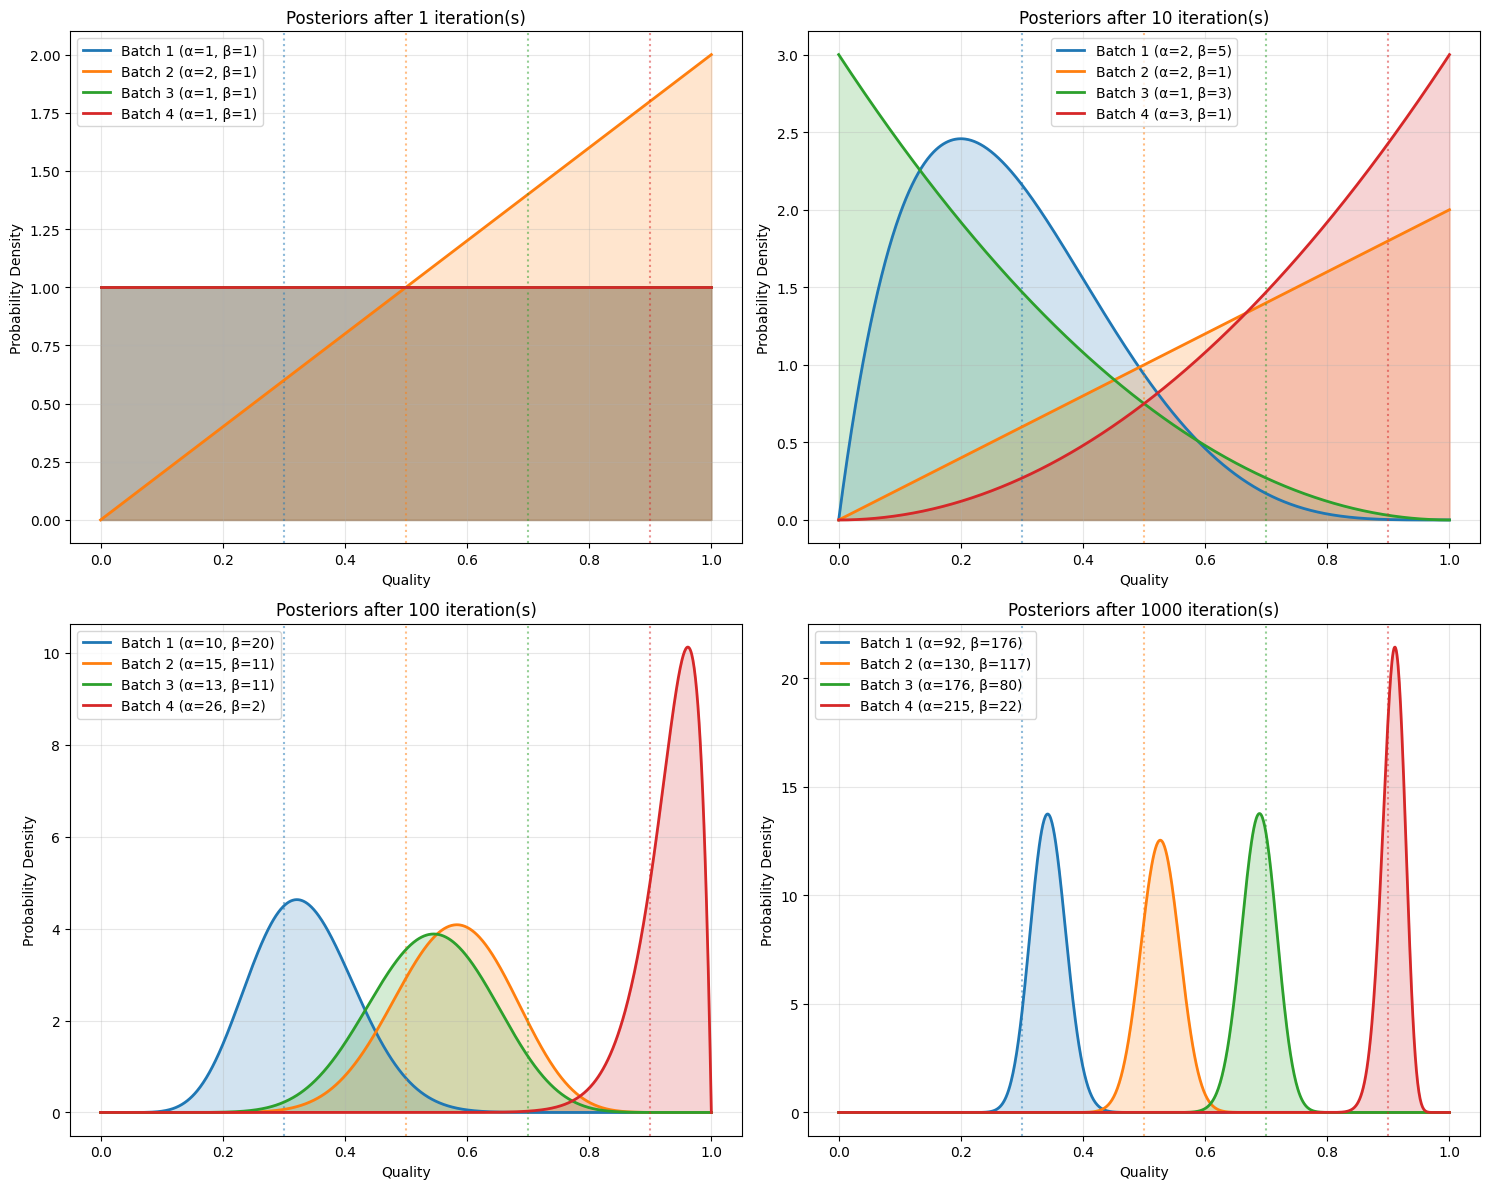

Batch 1 (quality=0.3): α=92, β=176, sampled 266 times, estimated quality=0.3433
Batch 2 (quality=0.5): α=130, β=117, sampled 245 times, estimated quality=0.5263
Batch 3 (quality=0.7): α=176, β=80, sampled 254 times, estimated quality=0.6875
Batch 4 (quality=0.9): α=215, β=22, sampled 235 times, estimated quality=0.9072
Batches: good=594, bad=406


In [46]:
qualities = [0.3, 0.5, 0.7, 0.9]
iterations_to_show = [1, 10, 100, 1000]
plot_posteriors(FactoryRandom, iterations_to_show, qualities)
summarize_strategy(FactoryRandom, qualities, n_iter=1000)

In random selection, all batches are chosen equally often. At 100 iterations the posteriors are still uncertain due to limited samples per batch. By 1000 iterations, Beta distributions converge to true values through accumulated evidence. However, random strategy fails to exploit this learned knowledge - it continues uniform sampling regardless of observed batch quality.

b) Sampling allows to favour the batches that performed best so far, but (due to randomness) allows also to give a chance to other batches

In [47]:
class FactoryAlmostBest:
    def __init__(self):
        self.batches = []
        self.systems = 0
        self.good = 0
        
    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.systems = 0
        self.good = 0
        
    def get_element(self):
        if np.random.rand() < 0.9:
            samples = [batch.sample_distribution() for batch in self.batches]
            choice = np.argmax(samples)
        else:
            choice = np.random.choice(len(self.batches))
        
        result = self.batches[choice].get_element()
        self.systems += 1
        self.good += int(result)

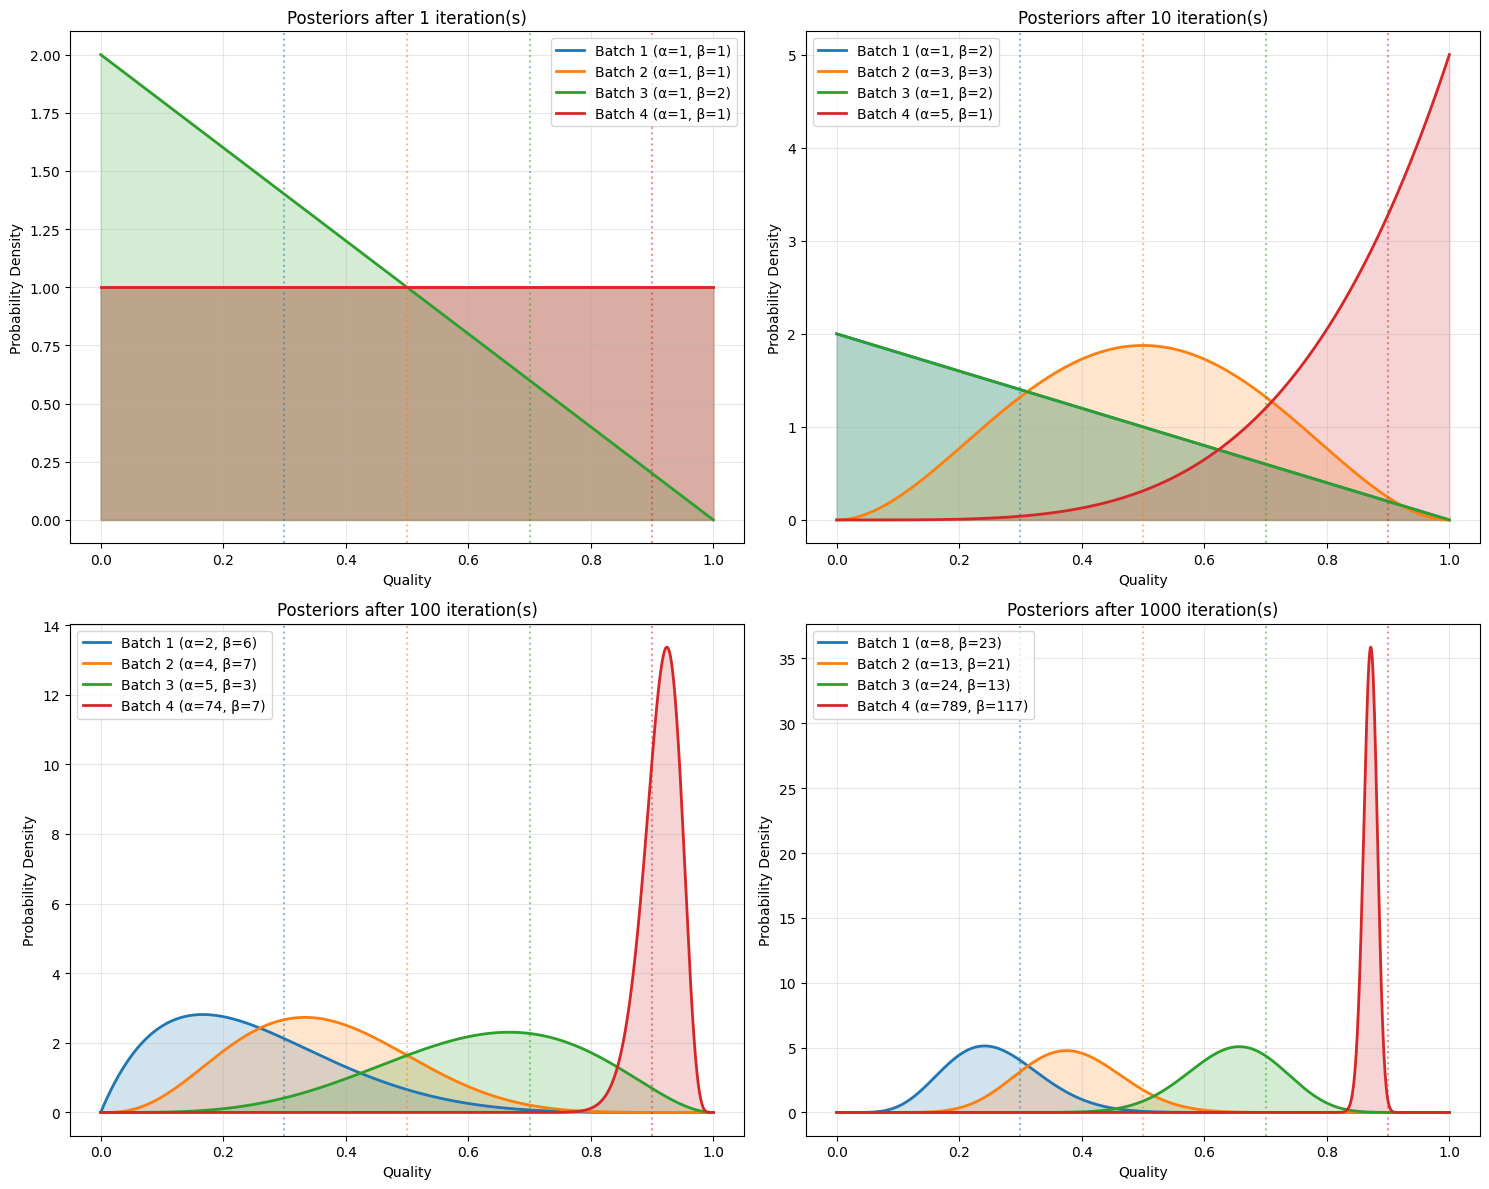

Batch 1 (quality=0.3): α=8, β=23, sampled 29 times, estimated quality=0.2581
Batch 2 (quality=0.5): α=13, β=21, sampled 32 times, estimated quality=0.3824
Batch 3 (quality=0.7): α=24, β=13, sampled 35 times, estimated quality=0.6486
Batch 4 (quality=0.9): α=789, β=117, sampled 904 times, estimated quality=0.8709
Batches: good=866, bad=134


In [48]:
qualities = [0.3, 0.5, 0.7, 0.9]
iterations_to_show = [1, 10, 100, 1000]
plot_posteriors(FactoryAlmostBest, iterations_to_show, qualities)
summarize_strategy(FactoryAlmostBest, qualities, n_iter=1000)

The epsilon-greedy approach (e=0.1) combines exploitation and exploration: 90% of the time it selects the best batch, while 10% explores randomly. This leads to faster convergence as by iteration 100, the best batch is already clearly visible. At 1000 iterations, Batch 4 dominates with significantly more samples than other batches, producing a sharp, narrow and therefore confident posterior. The trade-off is reduced exploration of alternative batches - their posteriors remain wider and therefore less certain. This strategy is effective when quick exploitation is needed, but risks missing better options if early samples are misleading.

c) Each resulting system, whether good or bad, increases our body of knowledge

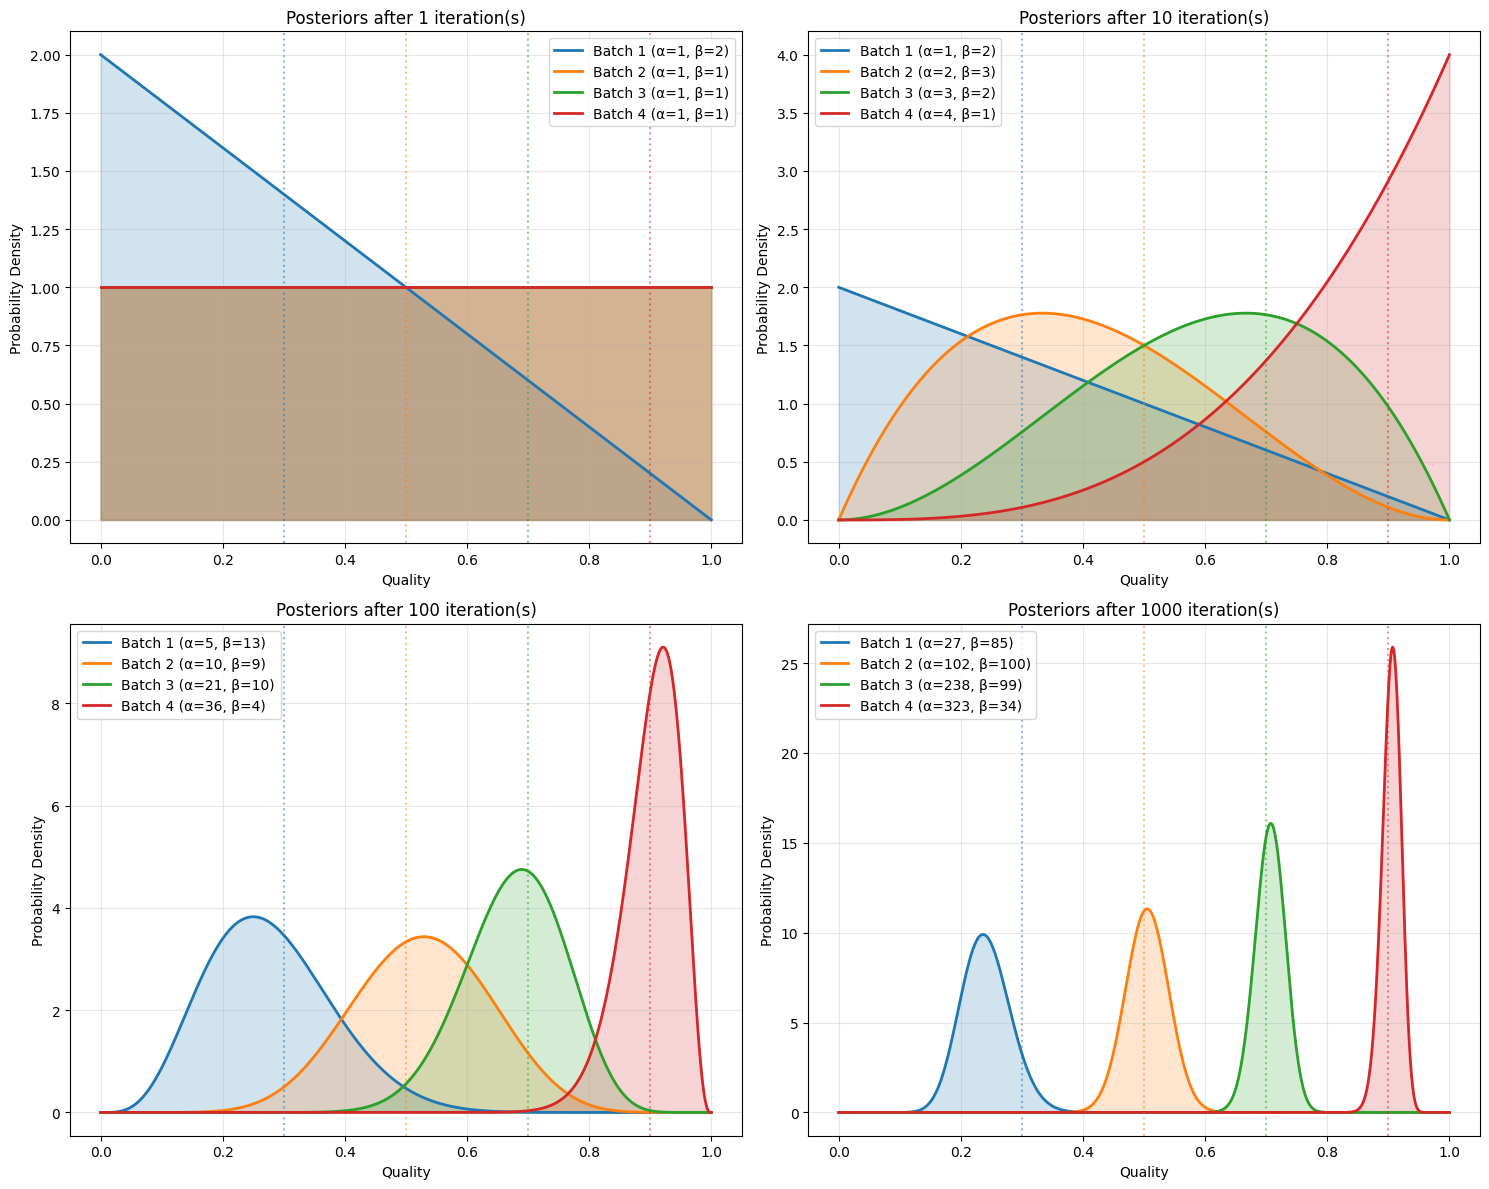

Batch 1 (quality=0.3): α=27, β=85, sampled 110 times, estimated quality=0.2411
Batch 2 (quality=0.5): α=102, β=100, sampled 200 times, estimated quality=0.5050
Batch 3 (quality=0.7): α=238, β=99, sampled 335 times, estimated quality=0.7062
Batch 4 (quality=0.9): α=323, β=34, sampled 355 times, estimated quality=0.9048
Batches: good=710, bad=290


In [49]:
qualities = [0.3, 0.5, 0.7, 0.9]
iterations_to_show = [1, 10, 100, 1000]
plot_posteriors(Factory, iterations_to_show, qualities)
summarize_strategy(Factory, qualities, n_iter=1000)

In [50]:
class FactoryAvoidBad:
    def __init__(self):
        self.batches = []
        self.systems = 0
        self.good = 0
        self.current_batch = 0
        
    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.systems = 0
        self.good = 0
        self.current_batch = 0
        
    def get_element(self):
        choice = self.current_batch
        result = self.batches[choice].get_element()
        
        if not result:  # If failure, move to next batch
            self.current_batch = (self.current_batch + 1) % len(self.batches)
        
        self.systems += 1
        self.good += int(result)

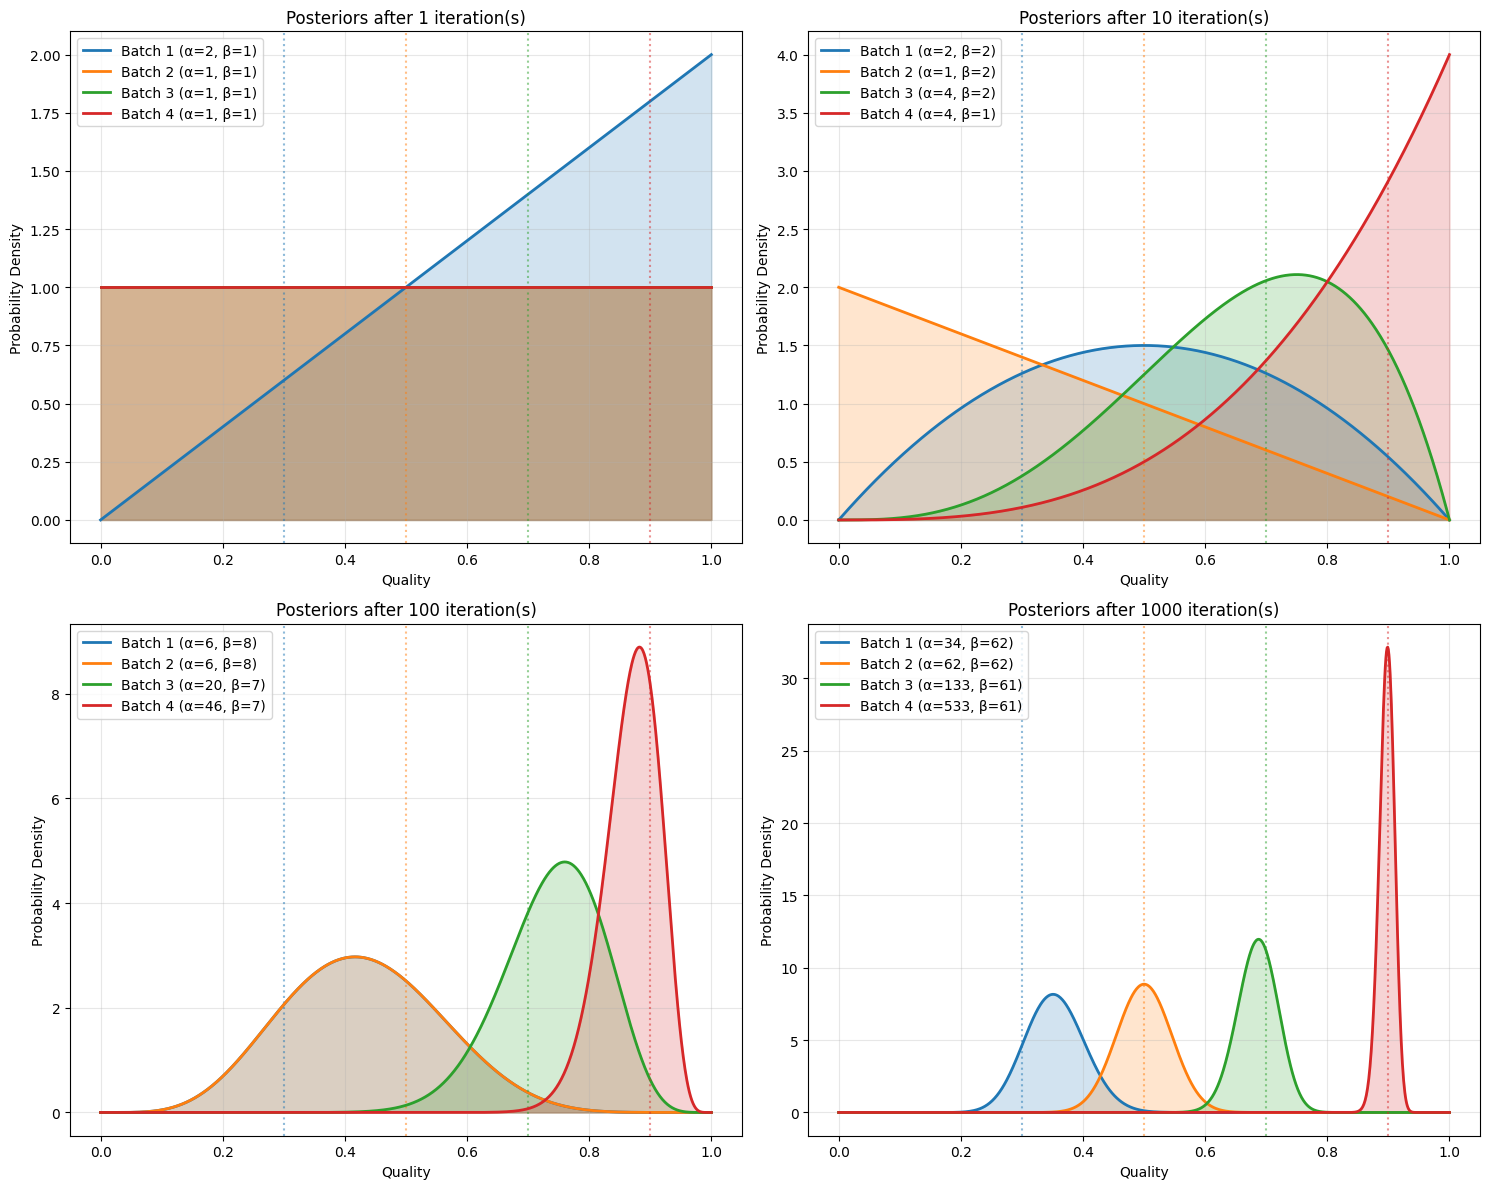

Batch 1 (quality=0.3): α=34, β=62, sampled 94 times, estimated quality=0.3542
Batch 2 (quality=0.5): α=62, β=62, sampled 122 times, estimated quality=0.5000
Batch 3 (quality=0.7): α=133, β=61, sampled 192 times, estimated quality=0.6856
Batch 4 (quality=0.9): α=533, β=61, sampled 592 times, estimated quality=0.8973
Batches: good=758, bad=242


In [52]:
qualities = [0.3, 0.5, 0.7, 0.9]
iterations_to_show = [1, 10, 100, 1000]
plot_posteriors(FactoryAvoidBad, iterations_to_show, qualities)
summarize_strategy(FactoryAvoidBad, qualities, n_iter=1000)

This strategy switches batches after each failure. Lower quality batches (0.3, 0.5) are quickly abandoned after failures, while higher quality batches (0.7, 0.9) accumulate more samples.

3. In real life it is possible that the quality of components from a manufacture changes in time. 
Implement “imperfect memory” in the Bayesian strategy that makes it gradually forget the 
learned parameters of Beta distribution for each batch. Check using an appropriate example.

In [53]:
class FactoryImperfectMemory:
    def __init__(self, decay_rate=0.90):
        self.batches = []
        self.systems = 0
        self.good = 0
        self.decay_rate = decay_rate
        self.count = 0
    
    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.systems = 0
        self.good = 0
        
    def get_element(self):
        for batch in self.batches:
            batch.alpha = 1 + (batch.alpha - 1) * self.decay_rate
            batch.beta = 1 + (batch.beta - 1) * self.decay_rate
        samples = [batch.sample_distribution() for batch in self.batches]
        choice = np.argmax(samples)
        result = self.batches[choice].get_element()
        
        self.systems += 1
        self.good += int(result)

In [54]:
def plot_posteriors_dynamic(factory_class, iterations_to_show, qualities, change_at=500, batch_to_change=0, new_quality=0.9):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    factory = factory_class()
    factory.set_batches(qualities)
    
    iteration_counter = 0
    quality_changed = False

    for idx, n_iter in enumerate(iterations_to_show):
        
        for i in range(iteration_counter, n_iter):
            
            if not quality_changed and i == change_at:
                factory.batches[batch_to_change].quality = new_quality
                quality_changed = True
            
            factory.get_element()
            
        iteration_counter = n_iter
        
        display_qualities = qualities.copy()
        if n_iter >= change_at:
            display_qualities[batch_to_change] = new_quality
        
        ax = axes[idx]
        x = np.linspace(0, 1, 1000)
        for i, batch in enumerate(factory.batches):
            pdf = beta_dist.pdf(x, batch.alpha, batch.beta)
            color = f'C{i}'
            ax.plot(x, pdf, label=f'Batch {i+1} (α={batch.alpha}, β={batch.beta})', linewidth=2, color=color)
            ax.fill_between(x, pdf, alpha=0.2, color=color)
            ax.axvline(x=display_qualities[i], color=color, linestyle=':', alpha=0.5)
        
        ax.set_xlabel('Quality')
        ax.set_ylabel('Probability Density')
        ax.set_title(f'Posteriors after {n_iter} iteration(s)')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    for i, batch in enumerate(factory.batches):
        estimated_quality = batch.alpha / (batch.alpha + batch.beta)
        print(f"Batch {i+1} (quality={qualities[i]}): α={batch.alpha}, β={batch.beta}, sampled {batch.count} times, estimated quality={estimated_quality:.4f}")

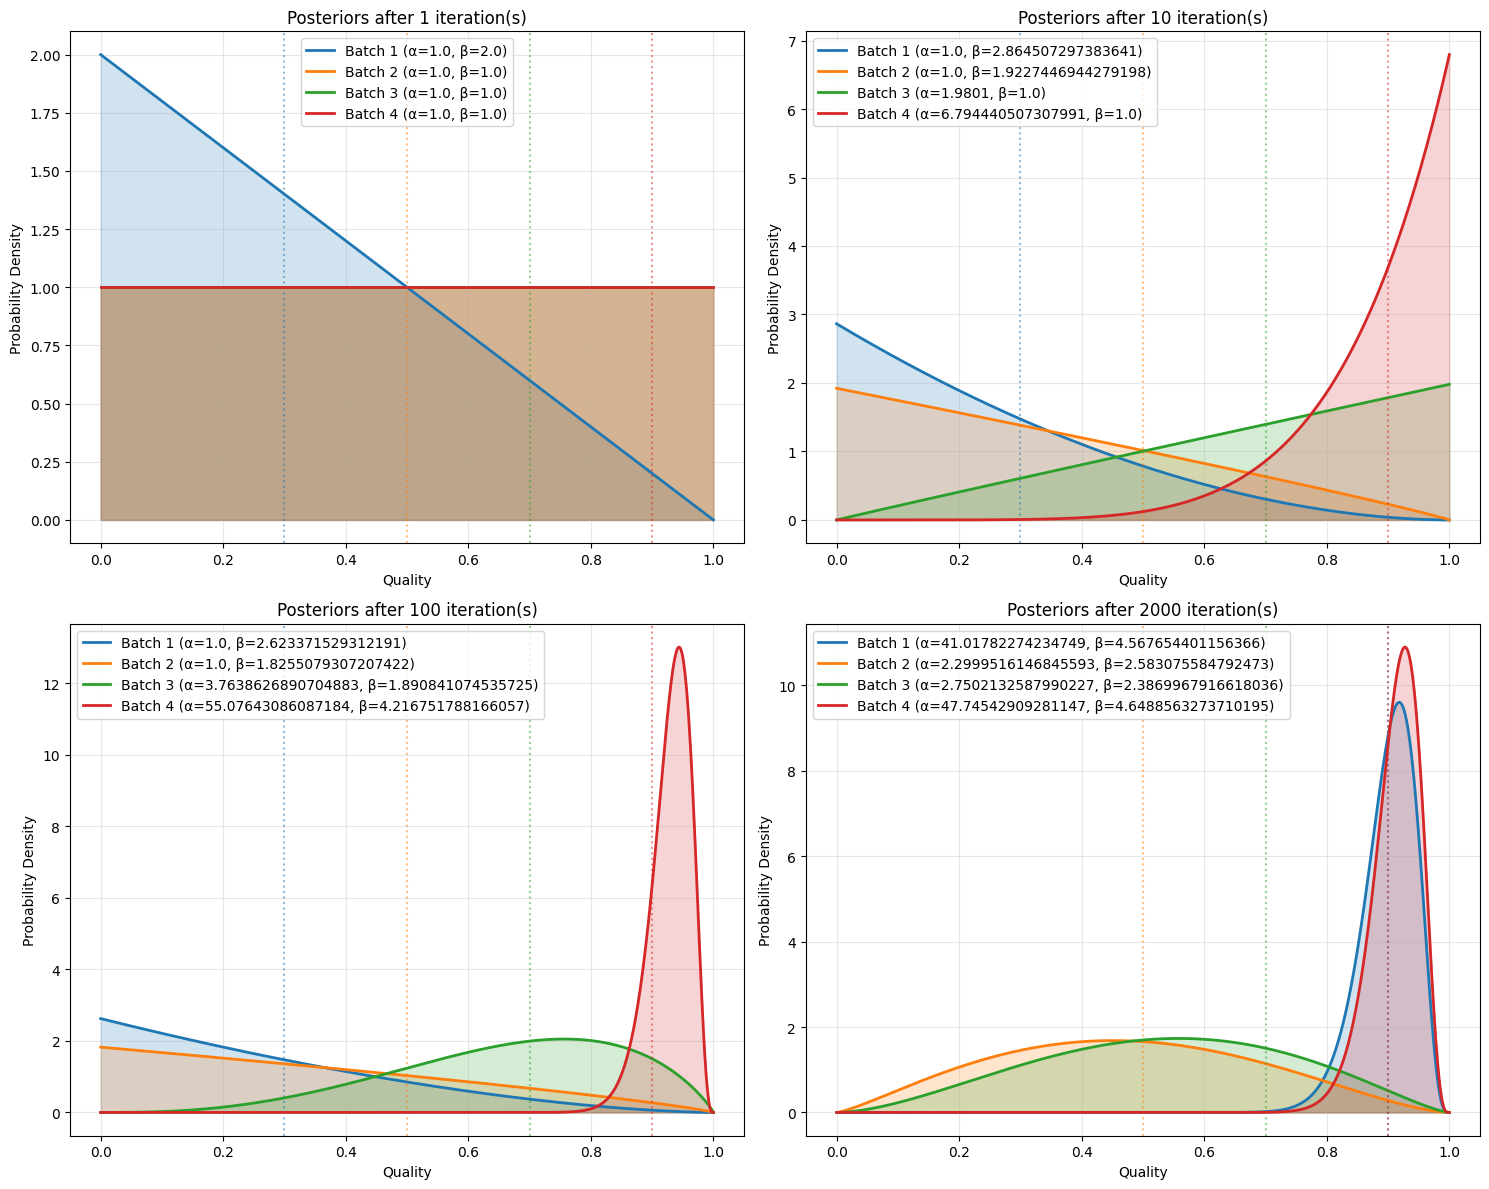

Batch 1 (quality=0.3): α=41.01782274234749, β=4.567654401156366, sampled 482 times, estimated quality=0.8998
Batch 2 (quality=0.5): α=2.2999516146845593, β=2.583075584792473, sampled 46 times, estimated quality=0.4710
Batch 3 (quality=0.7): α=2.7502132587990227, β=2.3869967916618036, sampled 111 times, estimated quality=0.5354
Batch 4 (quality=0.9): α=47.74542909281147, β=4.6488563273710195, sampled 1361 times, estimated quality=0.9113
Batches: good=1756, bad=244


In [58]:
qualities = [0.3, 0.5, 0.7, 0.9]
iterations_to_show = [1, 10, 100, 2000]
plot_posteriors_dynamic(
    lambda: FactoryImperfectMemory(decay_rate=0.99), 
    iterations_to_show, 
    qualities, 
    change_at=500, 
    batch_to_change=0, 
    new_quality=0.9
)
summarize_strategy_dynamic(
    lambda: FactoryImperfectMemory(decay_rate=0.99),
    qualities,
    n_iter=2000,
    change_at=500,
    batch_to_change=0,
    new_quality=0.9,
 )